### Imports and definitions

In [1]:
using DataFrames
using Plots
using CSV

In [2]:
plotlyjs();

WebIO._IJuliaInit()

In [3]:
pow(x,y) = x^y;

In [19]:
M_PI = π

r_h = 0.1
c = 1

Q = 1.8947
M = sqrt(4*r_h^2 + Q^2)

1.905226519340942

### Define analytical solutions

In [13]:
F1(R) = log((pow(M - Q + 2*R,2)*pow(M + Q + 2*R,2))/(pow(M,4) + pow(Q,4) + 16*pow(R,3)*(2*sqrt((M - Q)*(M + Q)) + R) - 8*pow(Q,2)*R*(sqrt((M - Q)*(M + Q)) + 3*R) + pow(M,2)*(-2*pow(Q,2) + 8*R*(sqrt((M - Q)*(M + Q)) + 3*R))))/2.

F0(R) = log((pow(sqrt(pow(M,2) - pow(Q,2)) + 2*R,2)*pow(-pow(M,2) + pow(Q,2) + 4*pow(R,2),2))/(pow(M - Q + 2*R,2)*pow(M + Q + 2*R,2)*(pow(M,2) - pow(Q,2) + 4*R*(-sqrt((M - Q)*(M + Q)) + R))))/2.

lphi(R) = 0

V(R) = Q/(2*sqrt(M_PI)*(1 + (pow(M,2) - pow(Q,2))/(4*pow(R,2)) + M/R)*R)

dV(R) = (-2*Q*(-pow(M,2) + pow(Q,2) + 4*pow(R,2)))/(sqrt(M_PI)*pow(M - Q + 2*R,2)*pow(M + Q + 2*R,2))

S0(R) = 1 - r_h/R
S1(R) = 1 + r_h/R;

### Fetch numerical data

In [24]:
CACTUS_ROOT = "/home/undercover/projects/cactus"
df = CSV.read("$CACTUS_ROOT/repos/magnetoscalar/MagScalarInit/etc/RN-01.csv", DataFrame, header=4)

α_E = 0.1
a = sqrt(4π)/α_E

# Extract each column into its own array
x_vec   = df.x[1:end-1]
F1_vec  = df.F1[1:end-1]
F0_vec  = df.F0[1:end-1]
phi_vec = df.phi[1:end-1]
V_vec   = df.V[1:end-1];
dV_vec  = df.dV[1:end-1];

In [10]:
r_vec = (r_h .+ c*x_vec) ./ (1 .- x_vec);

### Make comparission plots

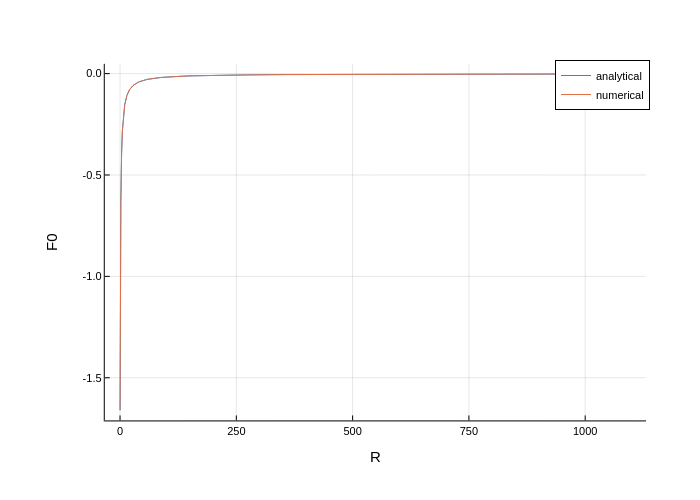

In [ ]:
plot(grid=true, gridalpha=0.2)

# R = 0 is a problem for F0(R)
plot!(r_vec[2:end], F0.(r_vec[2:end]), label="analytical")
plot!(r_vec[2:end], F0_vec[2:end],     label="numerical")

xlabel!("R")
ylabel!("F0")

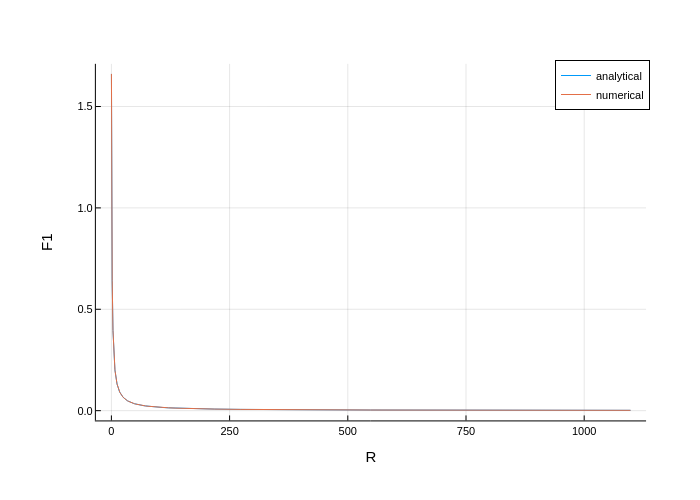

In [16]:
plot(grid=true, gridalpha=0.2)

# R = 0 is a problem for F0(R)
plot!(r_vec, F1.(r_vec), label="analytical")
plot!(r_vec, F1_vec,     label="numerical")

xlabel!("R")
ylabel!("F1")

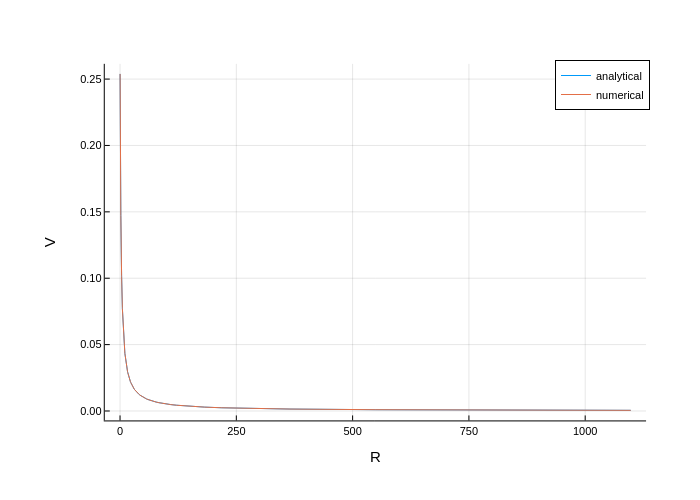

In [ ]:
plot(grid=true, gridalpha=0.2)

plot!(r_vec, V.(r_vec), label="analytical")
plot!(r_vec, V_vec/a,   label="numerical")  # re-scaling to match conventions

xlabel!("R")
ylabel!("V")

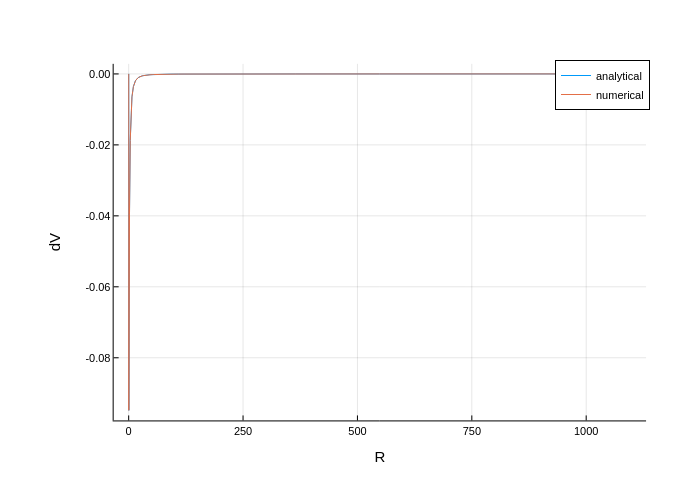

In [29]:
plot(grid=true, gridalpha=0.2)

plot!(r_vec, dV.(r_vec), label="analytical")
plot!(r_vec, dV_vec/a,   label="numerical")  # re-scaling to match conventions
xlabel!("R")
ylabel!("dV")